# Goal

Compare capture of linear and circular RNA barcodes in signal-seq VLPs.

pSL: linear barcodes

p139: circular barcodes

# Import

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import muon as mu
import cnsplots as cns
cns.settings.panel_label_fontname = "sans serif"

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/01_barcode_comparison_signalseq_SIG02_SIG03"

SIG02_H5MU = f"{IMPORTS_DIR}/SIG02/scanpy_outs/SIG02_full.h5mu"
SIG03_H5MU = f"{IMPORTS_DIR}/SIG03/scanpy_outs/SIG03_oBCDirect_full.h5mu"

ANALYSIS_OUTS = OUTS_DIR
os.makedirs(ANALYSIS_OUTS, exist_ok=True)

## Load data and assemble a combined per-cell table

One row per cell across both experiments: `chemistry` (`p139` / `pSL`), raw `viral` UMI, and raw `oBC_total` UMI (summed across that
chemistry's oBC barcodes).

In [3]:
def feature_counts(adata, feat, layer="counts"):
    sub = adata[:, feat]
    X = sub.layers[layer] if layer in sub.layers else sub.X
    X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
    return X.ravel()

def bc_matrix(bc):
    X = bc.layers["counts"] if "counts" in bc.layers else bc.X
    return pd.DataFrame(X.toarray() if hasattr(X, "toarray") else np.asarray(X),
                         index=bc.obs_names, columns=bc.var_names)

# --- SIG03 (p139): CD4 cells; delivered = 6e10 titer, no_virus_control = 0 titer ---
mdata_p139 = mu.read(SIG03_H5MU)
rna_p139, bc_p139 = mdata_p139.mod["rna"], mdata_p139.mod["bc"]
df_p139 = rna_p139.obs[["celltype", "titer"]].copy()
df_p139["viral"] = feature_counts(rna_p139, "p139-T7oBC5p-MS2")
bc_p139_counts = bc_matrix(bc_p139)
df_p139["oBC_total"] = bc_p139_counts[["p139-BC4", "p139-BC5"]].sum(axis=1)
df_p139 = df_p139[df_p139["celltype"] == "CD4"].copy()
df_p139["chemistry"] = "p139"
df_p139 = df_p139.query('titer == "6e10"').copy()  # only keep delivered and no-virus control groups

# --- SIG02 (pSL): all cells; cargo_library = lib, linker_control_NtermF = control ---
# NOTE: SIG02's "control" is a real virus (linker-only NtermF vLP), not a no-virus
# condition -- it is expected to carry viral transcript / NtermF-barcode signal.
# 5e10 viral titer is used and delivered twice
mdata_pSL = mu.read(SIG02_H5MU)
rna_pSL, bc_pSL = mdata_pSL.mod["rna"], mdata_pSL.mod["bc"]
df_pSL = rna_pSL.obs[["condition"]].copy()
viral_gene = [g for g in rna_pSL.var_names if g.startswith("pSL-")][0]
df_pSL["viral"] = feature_counts(rna_pSL, viral_gene)
df_pSL["oBC_total"] = bc_matrix(bc_pSL).sum(axis=1)
df_pSL["chemistry"] = "pSL"

combined = pd.concat(
    [df_p139[["chemistry", "viral", "oBC_total"]],
     df_pSL[["chemistry", "viral", "oBC_total"]]],
    ignore_index=True,
)

combined["log1p_viral"] = np.log1p(combined["viral"])
combined["log1p_oBC_total"] = np.log1p(combined["oBC_total"])
CHEMISTRIES = ["pSL","p139"]
combined.groupby(["chemistry"], observed=True).size()

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/mudat

chemistry
p139     4145
pSL     22360
dtype: int64

Same viral-vs-oBC comparison as above, but instead of summing UMI counts across all
oBC barcodes per cell (`oBC_total`), oBC UMI counts per barcode per cell are plotted.

In [4]:
# --- Long-format per-(cell, oBC) tables: raw UMI per individual barcode, not summed ---
bc_cols_p139 = ["p139-BC4", "p139-BC5"]
bc_cols_pSL = list(bc_matrix(bc_pSL).columns)  # all 18 pSLF-{gene}-BC{n} barcodes

def per_bc_long(rna, bc, viral_feat, bc_cols, meta_cols, query=None):
    obs = rna.obs[meta_cols].copy()
    obs["viral"] = feature_counts(rna, viral_feat)
    obs = obs.join(bc_matrix(bc)[bc_cols])
    if query is not None:
        obs = obs.query(query)
    return obs.melt(id_vars=["viral"], value_vars=bc_cols,
                     var_name="oBC_name", value_name="oBC_umi")

# only p139 has a titer column (and a celltype to restrict to CD4); pSL has neither
long_p139 = per_bc_long(
    rna_p139, bc_p139, "p139-T7oBC5p-MS2", bc_cols_p139,
    meta_cols=["celltype", "titer"],
    query='celltype == "CD4" and titer == "2e11"',
)
long_p139["chemistry"] = "p139"

long_pSL = per_bc_long(
    rna_pSL, bc_pSL, viral_gene, bc_cols_pSL,
    meta_cols=["condition"],
)
long_pSL["chemistry"] = "pSL"

combined_bc = pd.concat([long_p139, long_pSL], ignore_index=True)

combined_bc["log1p_viral"] = np.log1p(combined_bc["viral"])
combined_bc["log1p_oBC_umi"] = np.log1p(combined_bc["oBC_umi"])

## Comparison figure

Per-chemistry viral-vs-oBC scatter (log1p axes), colored by that chemistry's own
groups, with a KDE overlay on the virus-carrying group (`delivered` for p139,
`cargo_library` for pSL).

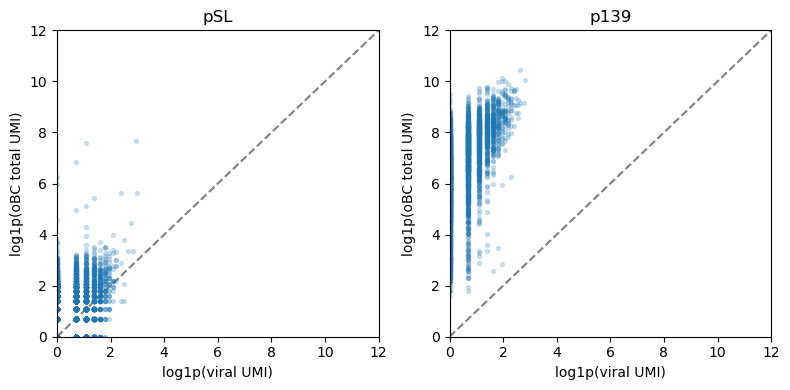

In [5]:
fig, axes = plt.subplots(1, len(CHEMISTRIES), figsize=(4 * len(CHEMISTRIES), 4))
KDE_GROUP = {"p139": "delivered", "pSL": "cargo_library"}

for ax, chem in zip(axes, CHEMISTRIES):
    d = combined[combined["chemistry"] == chem]
    ax.scatter(d["log1p_viral"], d["log1p_oBC_total"], s=8, alpha=0.2)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    ax.axline((0, 0), slope=1, color="grey", linestyle="--", zorder=0)
    ax.set_xlabel("log1p(viral UMI)"); ax.set_ylabel("log1p(oBC total UMI)")
    ax.set_title(chem)

fig.tight_layout()
fig.savefig(os.path.join(ANALYSIS_OUTS, "SIG02_vs_SIG03_viral_vs_oBC_comparison.pdf"), bbox_inches="tight")
plt.show()

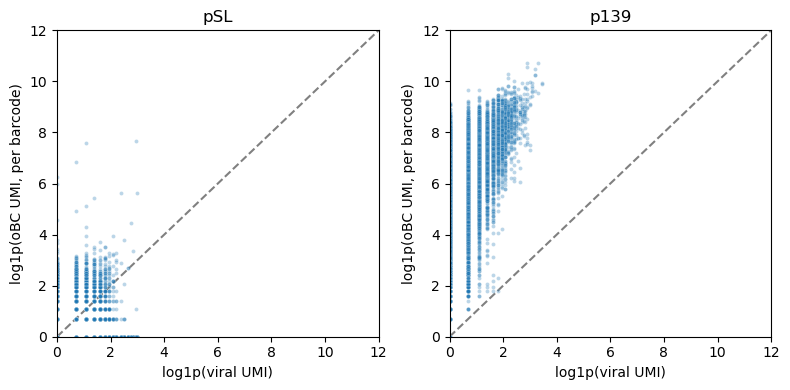

In [6]:
fig, axes = plt.subplots(1, len(CHEMISTRIES), figsize=(4 * len(CHEMISTRIES), 4))

for ax, chem in zip(axes, CHEMISTRIES):
    d = combined_bc[combined_bc["chemistry"] == chem]
    n_bc = d["oBC_name"].nunique()
    sns.scatterplot(data=d, x="log1p_viral", y="log1p_oBC_umi",
                     s=8, alpha=0.3, ax=ax)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    ax.axline((0, 0), slope=1, color="grey", linestyle="--", zorder=0)
    ax.set_xlabel("log1p(viral UMI)"); ax.set_ylabel("log1p(oBC UMI, per barcode)")
    ax.set_title(chem)

fig.tight_layout()
fig.savefig(os.path.join(ANALYSIS_OUTS, "SIG02_vs_SIG03_viral_vs_perBC_comparison.pdf"), bbox_inches="tight")
plt.show()

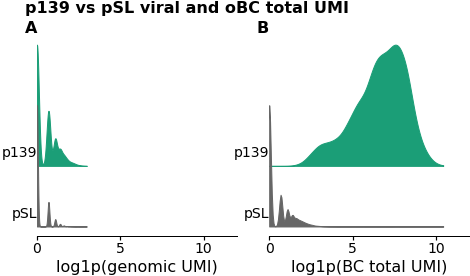

In [7]:
mp = cns.multipanel(
    max_width=485, title="p139 vs pSL viral and oBC total UMI", title_fontweight="bold", loc="left"
)
mp.panel("A", 100, 100)
ax = cns.ridgeplot(combined, x = "log1p_viral", y = "chemistry", cmap = "Dark2")
ax.set_xlim(0, 12)
ax.set_xlabel("log1p(genomic UMI)")
mp.panel("B", 100, 100)
ax = cns.ridgeplot(combined, x = "log1p_oBC_total", y = "chemistry", cmap = "Dark2")
ax.set_xlim(0, 12)
ax.set_xlabel("log1p(BC total UMI)")

cns.savefig(os.path.join(ANALYSIS_OUTS, "SIG02_vs_SIG03_ridgeplot_oBC_total.pdf"))

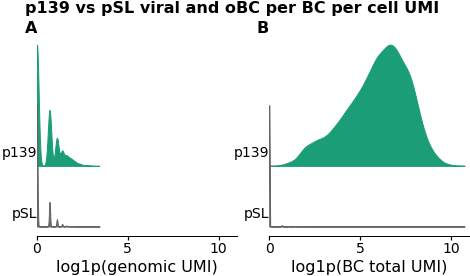

In [8]:
mp = cns.multipanel(
    max_width=485, title="p139 vs pSL viral and oBC per BC per cell UMI", title_fontweight="bold", loc="left"
)
mp.panel("A", 100, 100)
ax = cns.ridgeplot(combined_bc, x = "log1p_viral", y = "chemistry", cmap = "Dark2")
ax.set_xlabel("log1p(genomic UMI)")
ax.set_xlim(0, 11)
mp.panel("B", 100, 100)
ax = cns.ridgeplot(combined_bc, x = "log1p_oBC_umi", y = "chemistry", cmap = "Dark2")
ax.set_xlabel("log1p(BC total UMI)")
ax.set_xlim(0, 11)

cns.savefig(os.path.join(ANALYSIS_OUTS, "SIG02_vs_SIG03_ridgeplot_perBC.pdf"))

In [9]:
(combined.groupby(["chemistry"])
 .agg(mean_log1p_viral = ("log1p_viral", "mean"),
      mean_log1p_oBC_total = ("log1p_oBC_total", "mean"))
 .assign(mean_viral = lambda x: np.expm1(x["mean_log1p_viral"]),
         mean_oBC_total = lambda x: np.expm1(x["mean_log1p_oBC_total"])))

,mean_log1p_viral,mean_log1p_oBC_total,mean_viral,mean_oBC_total
chemistry,,,,
p139,0.518261,6.592333,0.679104,728.480652
pSL,0.204292,0.509210,0.226657,0.663976


In [10]:
(combined_bc.groupby(["chemistry"]).agg(mean_log1p_viral = ("log1p_viral", "mean"),
                                       mean_log1p_oBC_umi = ("log1p_oBC_umi", "mean"))
 .assign(mean_viral = lambda x: np.expm1(x["mean_log1p_viral"]),
         mean_oBC_umi = lambda x: np.expm1(x["mean_log1p_oBC_umi"])))

,mean_log1p_viral,mean_log1p_oBC_umi,mean_viral,mean_oBC_umi
chemistry,,,,
p139,0.569475,5.920317,0.767339,371.529663
pSL,0.204292,0.031836,0.226657,0.032348
